
# Introduction

This notebook is designed to evaluate the performance of an object detection model and analyze its failure cases. The workflow includes the following steps:

1. **Conversion of Ground Truth Data**: Convert BDD JSON annotations to the core assist format for evaluation.
2. **Evaluation of Predictions**: Compare the ground truth annotations with model predictions to compute evaluation metrics such as precision, recall, and F1 score.
3. **Failure Case Analysis**: Identify and analyze failure cases based on various factors such as image properties, weather conditions, scene types, and object characteristics.
4. **Visualization**: Generate plots to visualize the impact of different factors on model performance and failure cases.
5. **Insights and Recommendations**: Derive insights from the analysis to improve the model's performance in future iterations.

This notebook provides a comprehensive approach to understanding the strengths and weaknesses of the model, enabling targeted improvements.

### Note:

1. In this experiment, the model was trained only single class using data of 'car','bus','truck','rider','bike','motor','train' classes.
2. We have to convert BDD gt annotations to core_assist format for better analysis

In [ ]:
import sys
sys.path.append("..")

## Convert bdd json to core assist format for evaluation

In [ ]:
from core_assist.converter import converter

In [ ]:
json_path = "./data/bdd100k_labels_release/bdd100k/labels/bdd100k_labels_images_val.json"
image_dir = "./data/bdd100k_images_100k/bdd100k/images/100k/val"
output_path = "./data/object_detection/bdd_val_gt"
class_map = { 'car':0, 'bus':0, 'truck':0,'rider':0, 'bike':0, 'motor':0, 'train':0}


In [ ]:
converter.bdd_to_core_assist(json_path,image_dir= image_dir,class_map = class_map,output_path=output_path)

100%|██████████| 10000/10000 [06:26<00:00, 25.89it/s]


## Evaluate gt and predictions

In [1]:
from core_assist.metric import detection
import glob
import os

/anaconda/envs/yolo/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
gt_dir = "./data/object_detection/bdd_val_gt"
pred_dir = "./data/object_detection/bdd_val_infer"
gt_paths = list(glob.glob(os.path.join(gt_dir,"*.json")))
pred_paths = [os.path.join(pred_dir,os.path.basename(file_path)) for file_path in gt_paths]

In [3]:
print(f"total gt_paths :{len(gt_paths)}")

total gt_paths :10000


In [6]:
dataset_obj = detection.DatasetStats(gt_file_paths=gt_paths , pred_file_paths=pred_paths)

### Evaluate model for different thresholds 

In [14]:
dataset_obj.get_stats(conf_thresh=[0.5,0.6,0.7],iou_thresh=0.1)

Processing files: 100%|██████████| 10000/10000 [00:43<00:00, 230.71it/s]


Class-Level Metrics:
+------------------------+--------------+-------------+----------+------------+----------+-----------------+-------------------+
|   Confidence Threshold |   Class Name |   Precision |   Recall |   F1 Score |     mIoU |   Total GT Inst |   Total Pred Inst |
+========================+==============+=============+==========+============+==========+=================+===================+
|                    0.5 |            0 |    0.988778 | 0.65084  |   0.784984 | 0.93427  |          110471 |             72715 |
+------------------------+--------------+-------------+----------+------------+----------+-----------------+-------------------+
|                    0.6 |            0 |    0.994761 | 0.539653 |   0.699714 | 0.93285  |          110471 |             59930 |
+------------------------+--------------+-------------+----------+------------+----------+-----------------+-------------------+
|                    0.7 |            0 |    0.997893 | 0.43301  |   0.60395

### Plot metrices for better insight on confidence threshold and Precision and recall trade-off

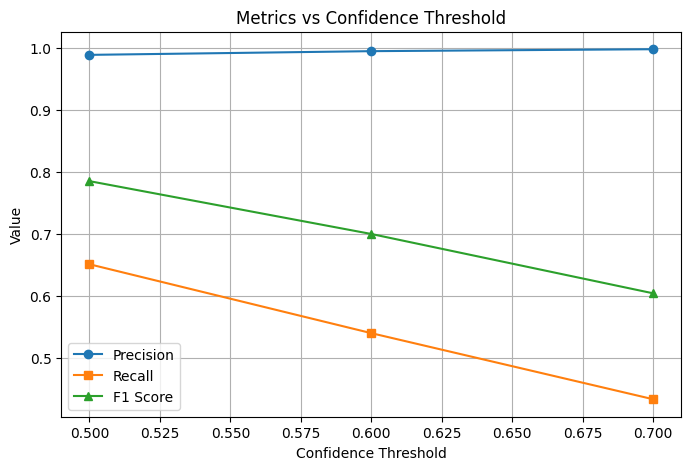

In [15]:
dataset_obj.plot_metric()

### Visualize samples

Plotting image 1: /mnt/03modeling/2_Aman/data/object_detection/val/c0dc5a95-b4bfcb2c.jpg


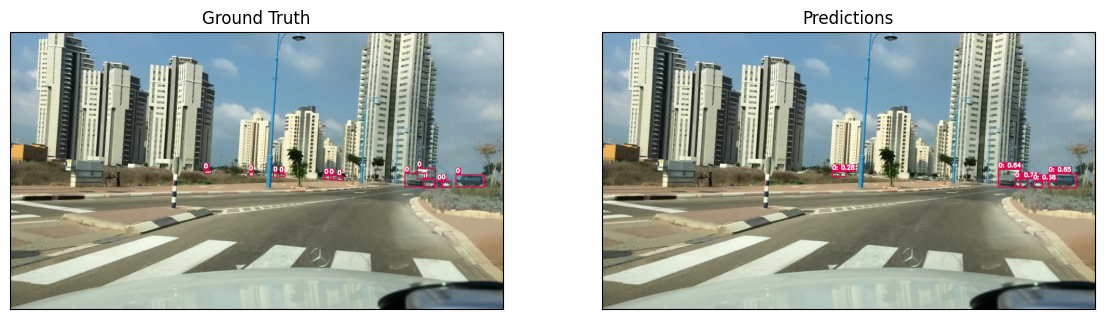

Plotting image 2: /mnt/03modeling/2_Aman/data/object_detection/val/c415a08c-d4f4488e.jpg


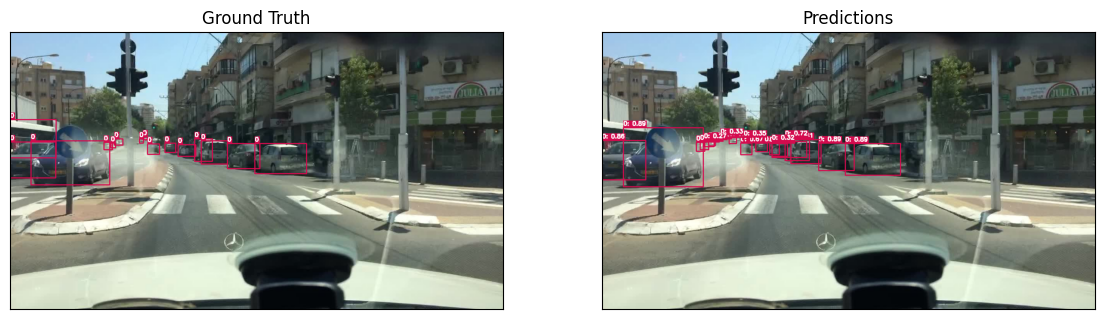

Plotting image 3: /mnt/03modeling/2_Aman/data/object_detection/val/c5e8ab3b-6e92761c.jpg


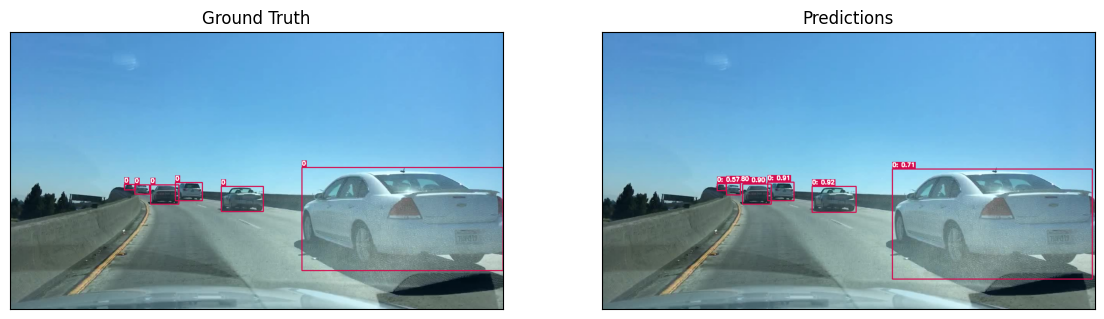

Plotting image 4: /mnt/03modeling/2_Aman/data/object_detection/val/c00cc83c-a6a9ce44.jpg


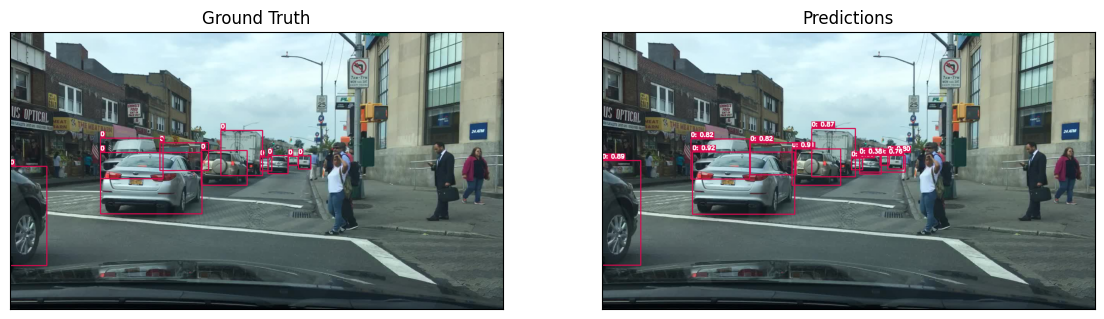

Plotting image 5: /mnt/03modeling/2_Aman/data/object_detection/val/bdcb68eb-8174c535.jpg


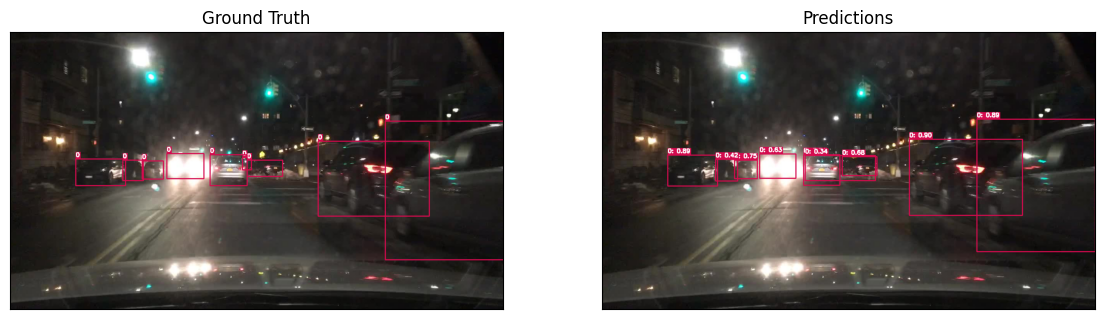

Plotting image 6: /mnt/03modeling/2_Aman/data/object_detection/val/c49c8353-30d3e9f2.jpg


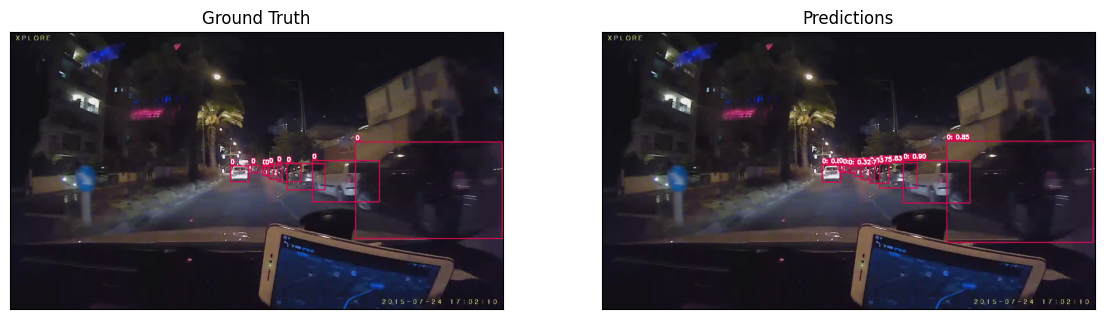

Plotting image 7: /mnt/03modeling/2_Aman/data/object_detection/val/b27cde22-56abd0e1.jpg


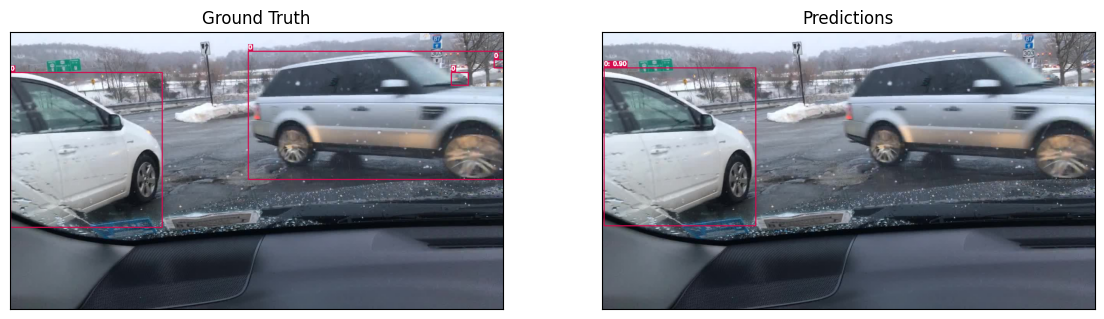

Plotting image 8: /mnt/03modeling/2_Aman/data/object_detection/val/c3999837-32005ed6.jpg


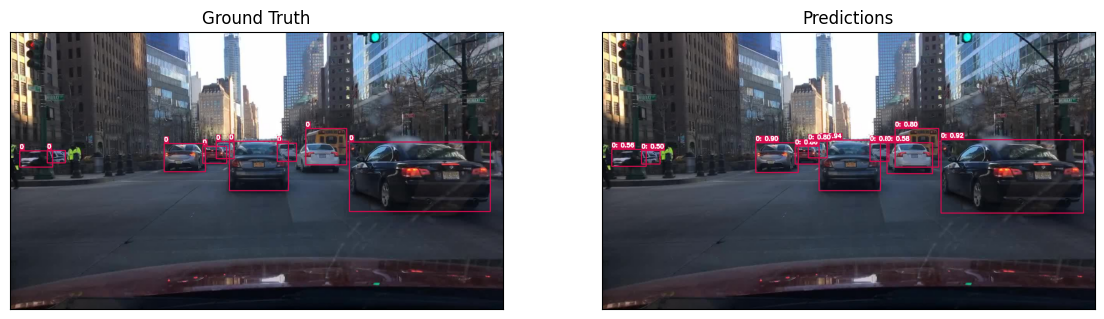

Plotting image 9: /mnt/03modeling/2_Aman/data/object_detection/val/b95dcb10-45d68fcc.jpg


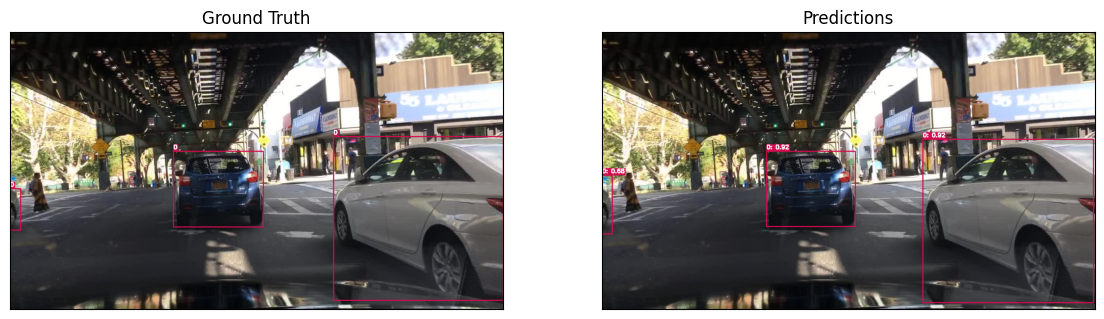

Plotting image 10: /mnt/03modeling/2_Aman/data/object_detection/val/b2afce7f-0cb9967a.jpg


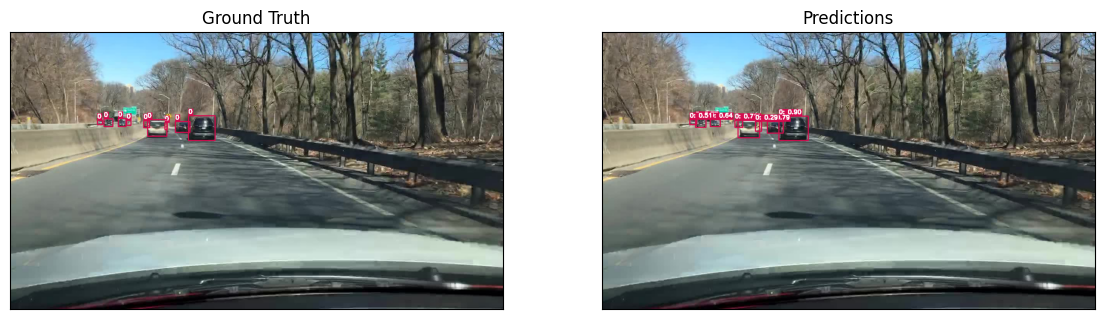

In [16]:
dataset_obj.plot(samples=10,show_stats=False)

## Plot failure cases

#### Filter by F1 score at per image level (less than threshold)

In [17]:
filtered_dataset_stats = dataset_obj.filter(conf_thresh =0.50 , by="f1_score" , thresh=0.7 , eq="<")

In [18]:
len(filtered_dataset_stats)

2692

Plotting image 1: /mnt/03modeling/2_Aman/data/object_detection/val/c57ec379-3d606dec.jpg
General Statistics:
+-----------+-----------------------+----------+-----------+--------+----------+
| Threshold |       Filename        | F1 Score | Precision | Recall | Mean IoU |
+-----------+-----------------------+----------+-----------+--------+----------+
|    0.5    | c57ec379-3d606dec.jpg |    0     |     0     |  0.0   |   0.0    |
|    0.6    | c57ec379-3d606dec.jpg |    0     |     0     |  0.0   |   0.0    |
|    0.7    | c57ec379-3d606dec.jpg |    0     |     0     |  0.0   |   0.0    |
+-----------+-----------------------+----------+-----------+--------+----------+

Class-wise Statistics:
+------------+------------+------------+------------+------------+------------+------------+
| Threshold  | Class Name |     TP     |     FP     |     FN     |    IoU     |     GT     |
+------------+------------+------------+------------+------------+------------+------------+
|    0.5     |     0 

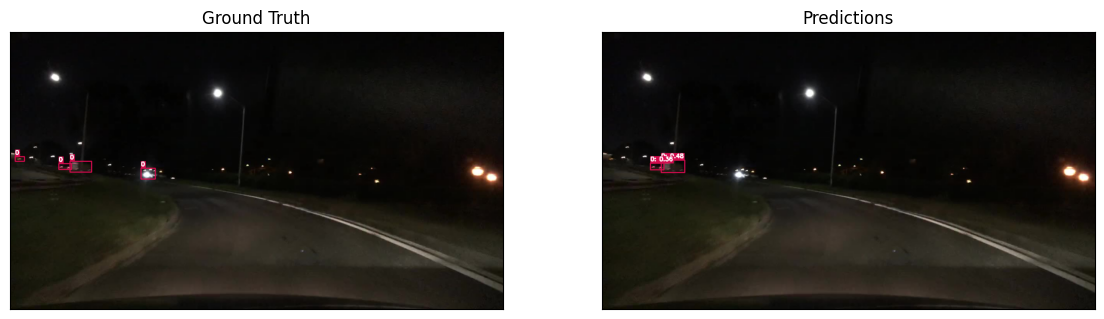

Plotting image 2: /mnt/03modeling/2_Aman/data/object_detection/val/be791a81-a6b53fef.jpg
General Statistics:
+-----------+-----------------------+--------------------+-----------+---------------------+--------------------+
| Threshold |       Filename        |      F1 Score      | Precision |       Recall        |      Mean IoU      |
+-----------+-----------------------+--------------------+-----------+---------------------+--------------------+
|    0.5    | be791a81-a6b53fef.jpg |        0.6         |    1.0    | 0.42857142857142855 | 0.985802423656355  |
|    0.6    | be791a81-a6b53fef.jpg | 0.4444444444444445 |    1.0    | 0.2857142857142857  | 0.9876211120403212 |
|    0.7    | be791a81-a6b53fef.jpg |        0.25        |    1.0    | 0.14285714285714285 | 0.9827168535646272 |
+-----------+-----------------------+--------------------+-----------+---------------------+--------------------+

Class-wise Statistics:
+------------+------------+------------+------------+------------+---

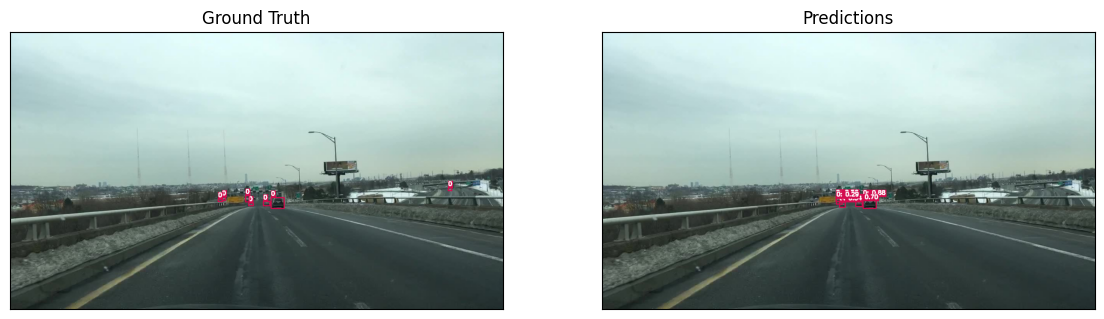

Plotting image 3: /mnt/03modeling/2_Aman/data/object_detection/val/b804f988-233a12a1.jpg
General Statistics:
+-----------+-----------------------+--------------------+-----------+---------------------+--------------------+
| Threshold |       Filename        |      F1 Score      | Precision |       Recall        |      Mean IoU      |
+-----------+-----------------------+--------------------+-----------+---------------------+--------------------+
|    0.5    | b804f988-233a12a1.jpg | 0.6666666666666666 |    1.0    |         0.5         | 0.8866286085125389 |
|    0.6    | b804f988-233a12a1.jpg |        0.5         |    1.0    | 0.3333333333333333  | 0.9719634952541628 |
|    0.7    | b804f988-233a12a1.jpg | 0.2857142857142857 |    1.0    | 0.16666666666666666 | 0.9810540689252003 |
+-----------+-----------------------+--------------------+-----------+---------------------+--------------------+

Class-wise Statistics:
+------------+------------+------------+------------+------------+---

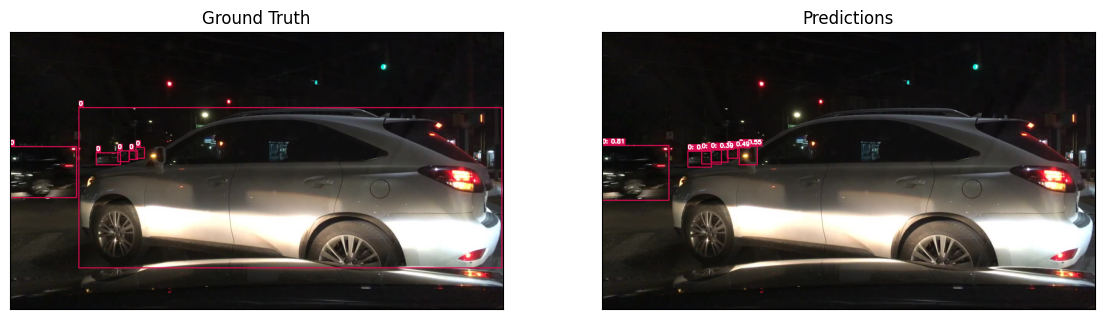

Plotting image 4: /mnt/03modeling/2_Aman/data/object_detection/val/b6a6df2d-8f9cc4cf.jpg
General Statistics:
+-----------+-----------------------+--------------------+-----------+---------------------+--------------------+
| Threshold |       Filename        |      F1 Score      | Precision |       Recall        |      Mean IoU      |
+-----------+-----------------------+--------------------+-----------+---------------------+--------------------+
|    0.5    | b6a6df2d-8f9cc4cf.jpg | 0.6470588235294118 |    1.0    | 0.4782608695652174  | 0.9549692404044818 |
|    0.6    | b6a6df2d-8f9cc4cf.jpg | 0.5161290322580645 |    1.0    | 0.34782608695652173 | 0.9520543918172367 |
|    0.7    | b6a6df2d-8f9cc4cf.jpg | 0.4666666666666667 |    1.0    | 0.30434782608695654 | 0.9531886614788743 |
+-----------+-----------------------+--------------------+-----------+---------------------+--------------------+

Class-wise Statistics:
+------------+------------+------------+------------+------------+---

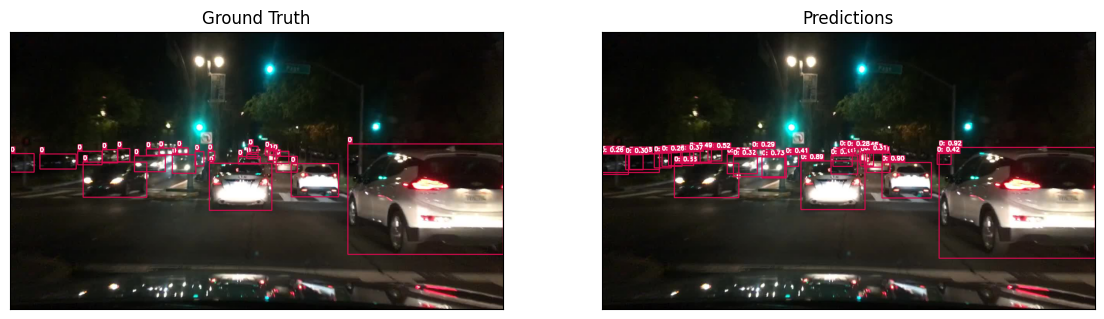

Plotting image 5: /mnt/03modeling/2_Aman/data/object_detection/val/b61f19ba-48885e8c.jpg
General Statistics:
+-----------+-----------------------+--------------------+-----------+---------------------+--------------------+
| Threshold |       Filename        |      F1 Score      | Precision |       Recall        |      Mean IoU      |
+-----------+-----------------------+--------------------+-----------+---------------------+--------------------+
|    0.5    | b61f19ba-48885e8c.jpg | 0.6060606060606061 |    1.0    | 0.43478260869565216 | 0.9589747761490546 |
|    0.6    | b61f19ba-48885e8c.jpg | 0.5161290322580645 |    1.0    | 0.34782608695652173 | 0.9553498260560022 |
|    0.7    | b61f19ba-48885e8c.jpg | 0.4666666666666667 |    1.0    | 0.30434782608695654 | 0.9546812080744596 |
+-----------+-----------------------+--------------------+-----------+---------------------+--------------------+

Class-wise Statistics:
+------------+------------+------------+------------+------------+---

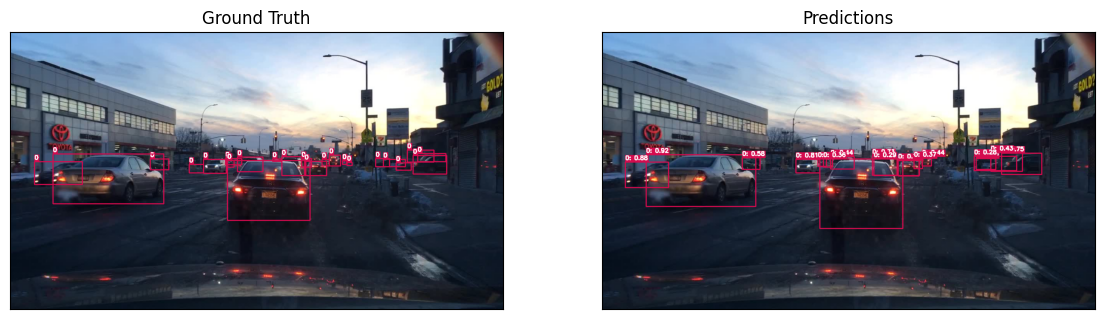

Plotting image 6: /mnt/03modeling/2_Aman/data/object_detection/val/c57a466b-876d29df.jpg
General Statistics:
+-----------+-----------------------+--------------------+-----------+---------------------+--------------------+
| Threshold |       Filename        |      F1 Score      | Precision |       Recall        |      Mean IoU      |
+-----------+-----------------------+--------------------+-----------+---------------------+--------------------+
|    0.5    | c57a466b-876d29df.jpg | 0.4444444444444445 |    1.0    | 0.2857142857142857  | 0.9103232225081466 |
|    0.6    | c57a466b-876d29df.jpg |        0.25        |    1.0    | 0.14285714285714285 | 0.9344198724127434 |
|    0.7    | c57a466b-876d29df.jpg |        0.25        |    1.0    | 0.14285714285714285 | 0.9344198724127434 |
+-----------+-----------------------+--------------------+-----------+---------------------+--------------------+

Class-wise Statistics:
+------------+------------+------------+------------+------------+---

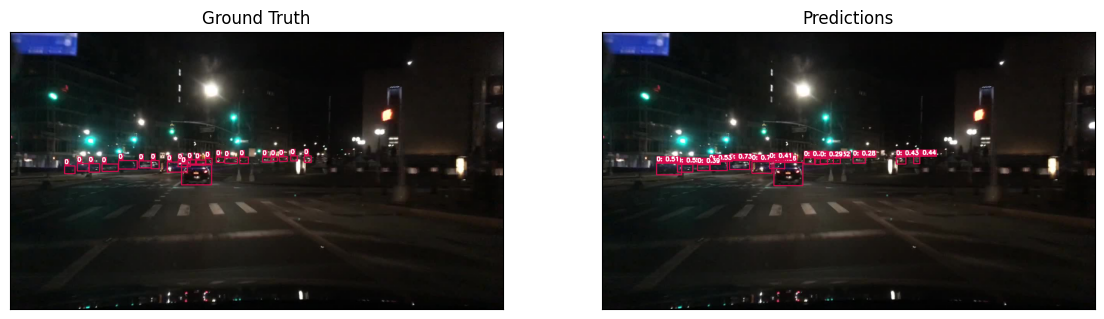

Plotting image 7: /mnt/03modeling/2_Aman/data/object_detection/val/c5f0cacd-26e83cd1.jpg
General Statistics:
+-----------+-----------------------+---------------------+-----------+--------+-------------------+
| Threshold |       Filename        |      F1 Score       | Precision | Recall |     Mean IoU      |
+-----------+-----------------------+---------------------+-----------+--------+-------------------+
|    0.5    | c5f0cacd-26e83cd1.jpg | 0.33333333333333337 |    1.0    |  0.2   | 0.910331624598496 |
|    0.6    | c5f0cacd-26e83cd1.jpg |          0          |     0     |  0.0   |        0.0        |
|    0.7    | c5f0cacd-26e83cd1.jpg |          0          |     0     |  0.0   |        0.0        |
+-----------+-----------------------+---------------------+-----------+--------+-------------------+

Class-wise Statistics:
+------------+------------+------------+------------+------------+-------------------+------------+
| Threshold  | Class Name |     TP     |     FP     |     FN

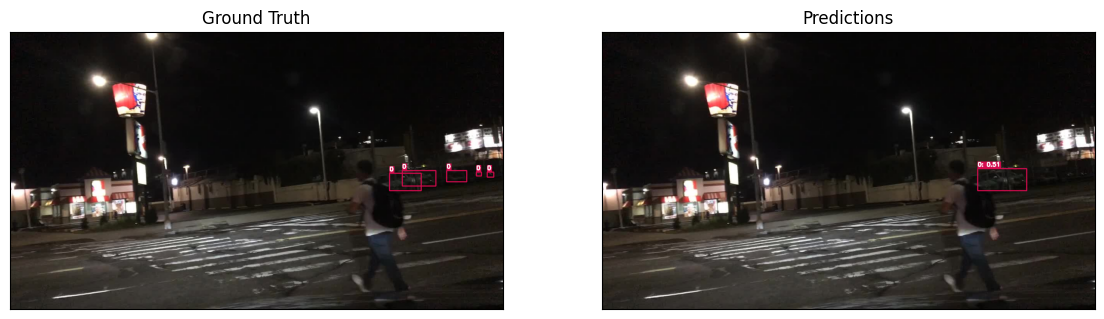

Plotting image 8: /mnt/03modeling/2_Aman/data/object_detection/val/c614be17-f1d896e0.jpg
General Statistics:
+-----------+-----------------------+--------------------+-----------+--------------------+--------------------+
| Threshold |       Filename        |      F1 Score      | Precision |       Recall       |      Mean IoU      |
+-----------+-----------------------+--------------------+-----------+--------------------+--------------------+
|    0.5    | c614be17-f1d896e0.jpg | 0.6666666666666666 |    1.0    |        0.5         | 0.9829782553911631 |
|    0.6    | c614be17-f1d896e0.jpg | 0.5882352941176471 |    1.0    | 0.4166666666666667 | 0.9854711813542425 |
|    0.7    | c614be17-f1d896e0.jpg | 0.5882352941176471 |    1.0    | 0.4166666666666667 | 0.9854711813542425 |
+-----------+-----------------------+--------------------+-----------+--------------------+--------------------+

Class-wise Statistics:
+------------+------------+------------+------------+------------+----------

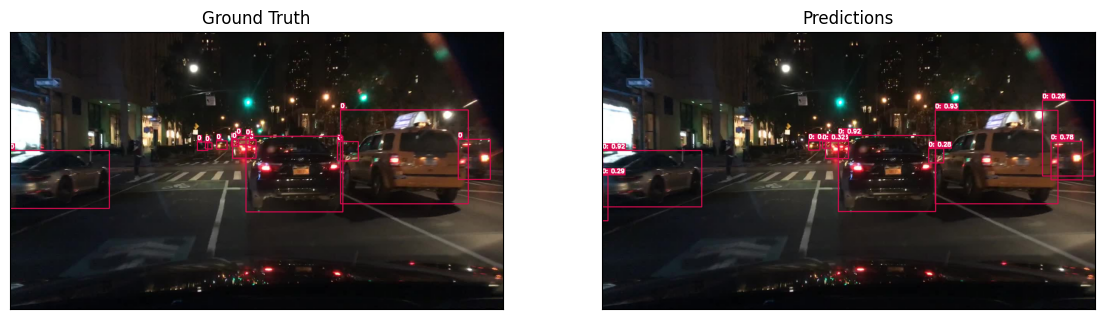

Plotting image 9: /mnt/03modeling/2_Aman/data/object_detection/val/b86f9b95-e4651840.jpg
General Statistics:
+-----------+-----------------------+----------+-----------+--------+----------+
| Threshold |       Filename        | F1 Score | Precision | Recall | Mean IoU |
+-----------+-----------------------+----------+-----------+--------+----------+
|    0.5    | b86f9b95-e4651840.jpg |    0     |     0     |   0    |    0     |
|    0.6    | b86f9b95-e4651840.jpg |    0     |     0     |   0    |    0     |
|    0.7    | b86f9b95-e4651840.jpg |    0     |     0     |   0    |    0     |
+-----------+-----------------------+----------+-----------+--------+----------+

Class-wise Statistics:
+------------+------------+------------+------------+------------+------------+------------+
| Threshold  | Class Name |     TP     |     FP     |     FN     |    IoU     |     GT     |
+------------+------------+------------+------------+------------+------------+------------+
| ---------- | ------

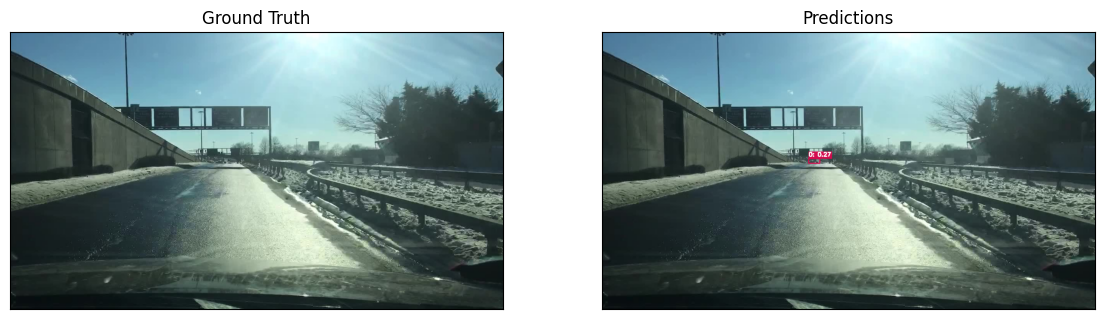

Plotting image 10: /mnt/03modeling/2_Aman/data/object_detection/val/c586b898-d44df97d.jpg
General Statistics:
+-----------+-----------------------+--------------------+-----------+--------+--------------------+
| Threshold |       Filename        |      F1 Score      | Precision | Recall |      Mean IoU      |
+-----------+-----------------------+--------------------+-----------+--------+--------------------+
|    0.5    | c586b898-d44df97d.jpg | 0.6666666666666666 |    1.0    |  0.5   | 0.9601721729155276 |
|    0.6    | c586b898-d44df97d.jpg |         0          |     0     |  0.0   |        0.0         |
|    0.7    | c586b898-d44df97d.jpg |         0          |     0     |  0.0   |        0.0         |
+-----------+-----------------------+--------------------+-----------+--------+--------------------+

Class-wise Statistics:
+------------+------------+------------+------------+------------+--------------------+------------+
| Threshold  | Class Name |     TP     |     FP     |     

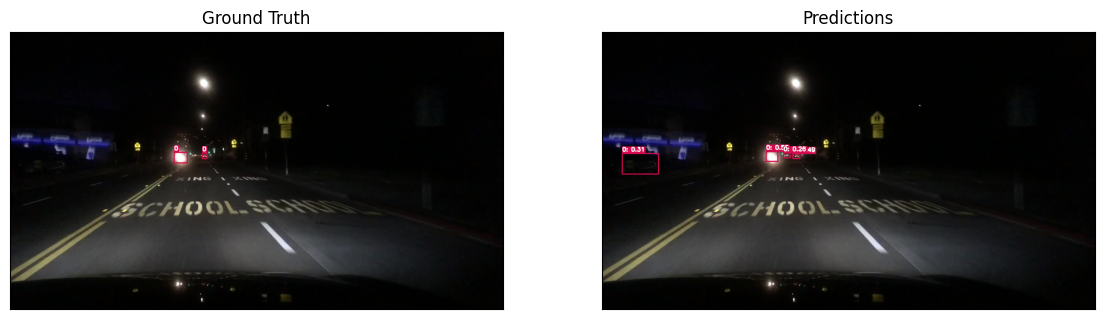

In [19]:
filtered_dataset_stats.plot(samples=10)

### Check failure cases image stats and annotation stats

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
failure_img_names = filtered_dataset_stats.all_image_stats.keys()

In [22]:
len(failure_img_names)

2692

In [55]:
img_df = pd.read_csv("/mnt/03modeling/2_Aman/data/object_detection/image_features.csv")
anno_df = pd.read_csv("/mnt/03modeling/2_Aman/data/object_detection/object_detection_annotations.csv")
anno_df = anno_df[anno_df.category.isin(['car', 'bus', 'truck','rider', 'bike', 'motor', 'train'])]
combined_df = pd.merge(anno_df, img_df, on="image_name", how="inner")
combined_df.head(2)

,image_name,category,x1,y1,x2,y2,occluded,truncated,trafficLightColor,image_width,image_height,brightness,sharpness,contrast,rgb_mean,rgb_std,size(MBs),image_weather,image_scene,image_timeofday
0,b1c66a42-6f7d68ca.jpg,car,205.879417,338.141346,281.992413,388.051507,True,False,none,1280,720,91.401376,3.430301,65.848841,"[96.46300672743055, 90.86204427083334, 84.4848...","[67.58140221492889, 65.83946795573966, 67.5368...",0.0508,overcast,city street,daytime
1,b1c66a42-6f7d68ca.jpg,car,47.414654,344.380116,129.766420,400.529049,True,False,none,1280,720,91.401376,3.430301,65.848841,"[96.46300672743055, 90.86204427083334, 84.4848...","[67.58140221492889, 65.83946795573966, 67.5368...",0.0508,overcast,city street,daytime


In [56]:
combined_df["failure"] = False

In [57]:
combined_df["failure"] = combined_df["image_name"].isin(failure_img_names)
combined_df.head(2)

,image_name,category,x1,y1,x2,y2,occluded,truncated,trafficLightColor,image_width,...,brightness,sharpness,contrast,rgb_mean,rgb_std,size(MBs),image_weather,image_scene,image_timeofday,failure
0,b1c66a42-6f7d68ca.jpg,car,205.879417,338.141346,281.992413,388.051507,True,False,none,1280,...,91.401376,3.430301,65.848841,"[96.46300672743055, 90.86204427083334, 84.4848...","[67.58140221492889, 65.83946795573966, 67.5368...",0.0508,overcast,city street,daytime,False
1,b1c66a42-6f7d68ca.jpg,car,47.414654,344.380116,129.766420,400.529049,True,False,none,1280,...,91.401376,3.430301,65.848841,"[96.46300672743055, 90.86204427083334, 84.4848...","[67.58140221492889, 65.83946795573966, 67.5368...",0.0508,overcast,city street,daytime,False


### Analyse impact of light conditions on prediction

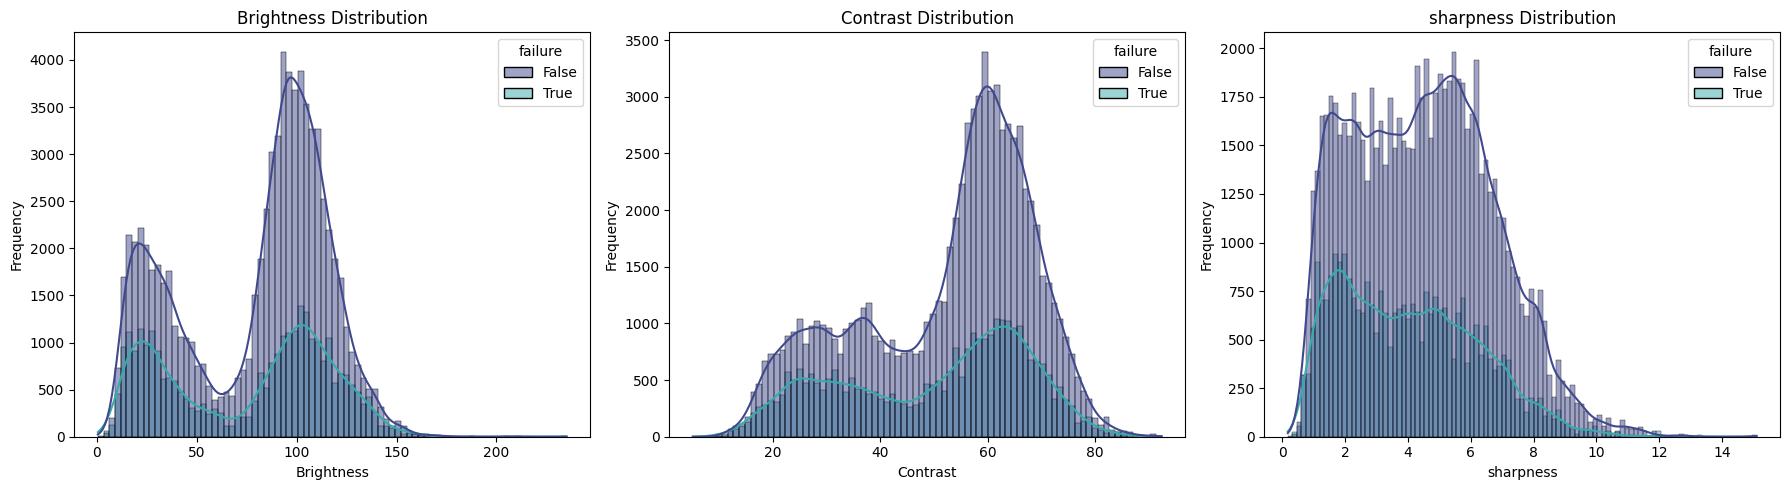

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

# Brightness distribution
sns.histplot(data=combined_df, x="brightness", hue="failure", kde=True, ax=axes[0], palette="mako")
axes[0].set_title("Brightness Distribution")
axes[0].set_xlabel("Brightness")
axes[0].set_ylabel("Frequency")

# Contrast distribution
sns.histplot(data=combined_df, x="contrast", hue="failure", kde=True, ax=axes[1], palette="mako")
axes[1].set_title("Contrast Distribution")
axes[1].set_xlabel("Contrast")
axes[1].set_ylabel("Frequency")

# Saturation distribution
sns.histplot(data=combined_df, x="sharpness", hue="failure", kde=True, ax=axes[2], palette="mako")
axes[2].set_title("sharpness Distribution")
axes[2].set_xlabel("sharpness")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

There is impact of low sharpness (bluriness) on failure cases. 

#### Check images

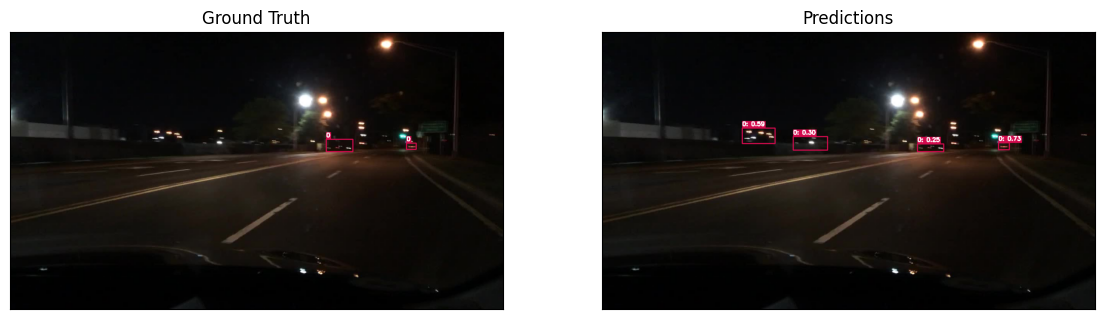

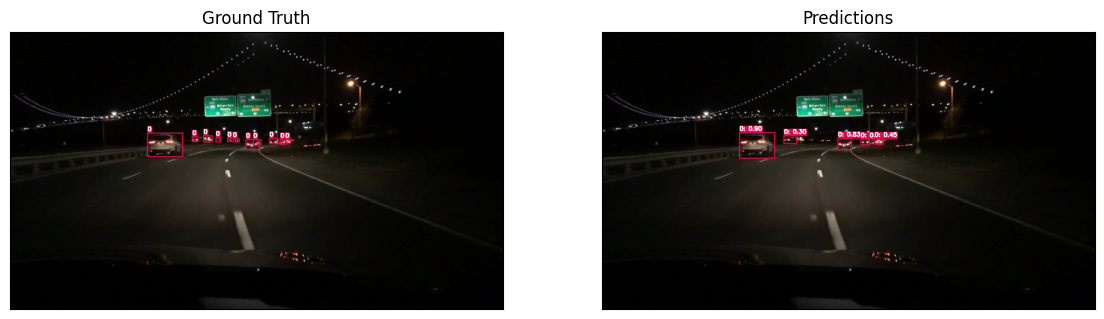

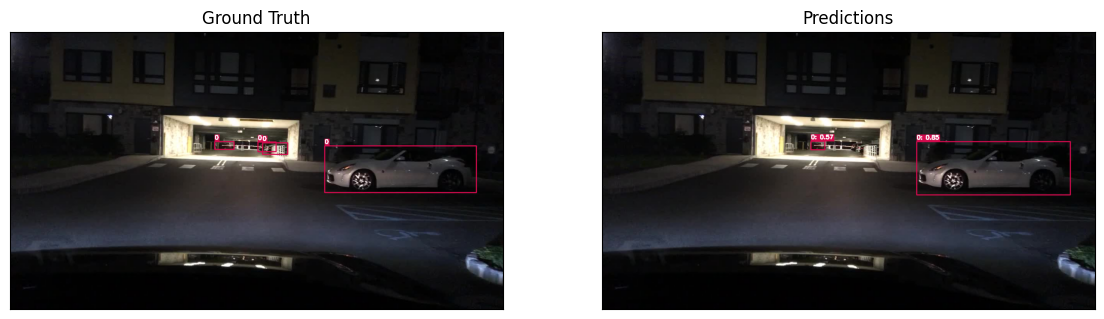

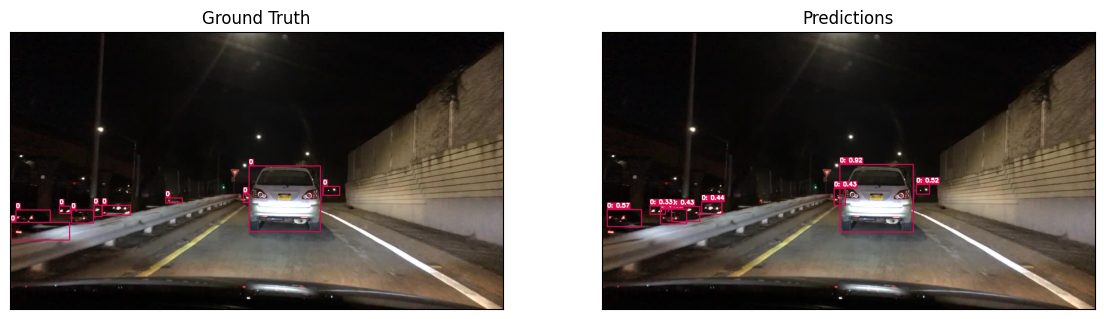

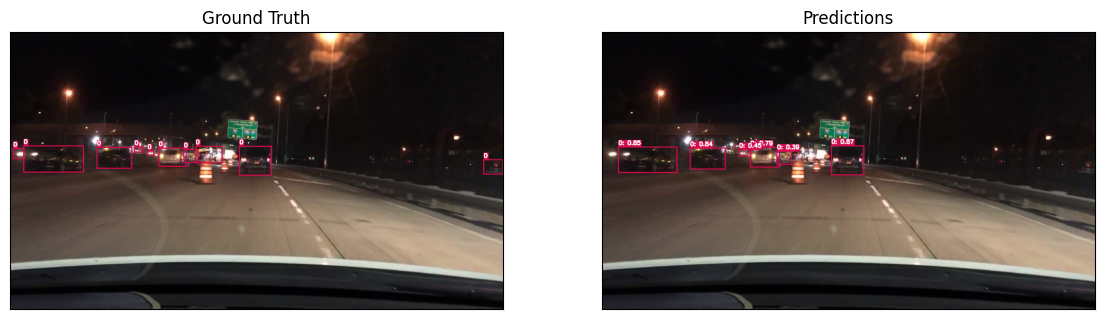

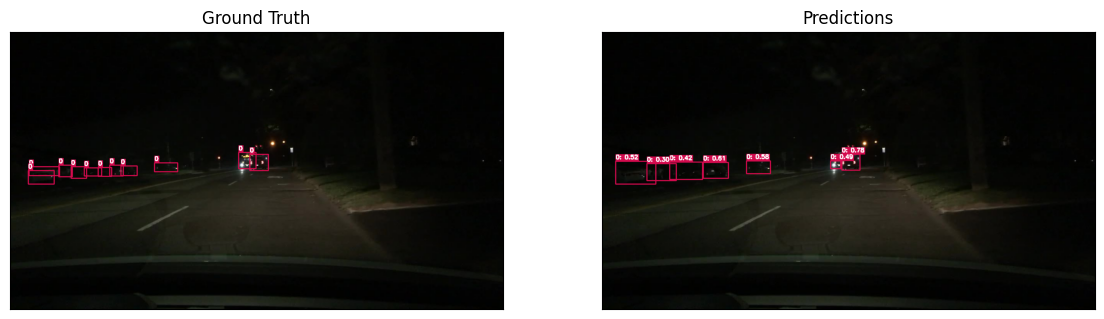

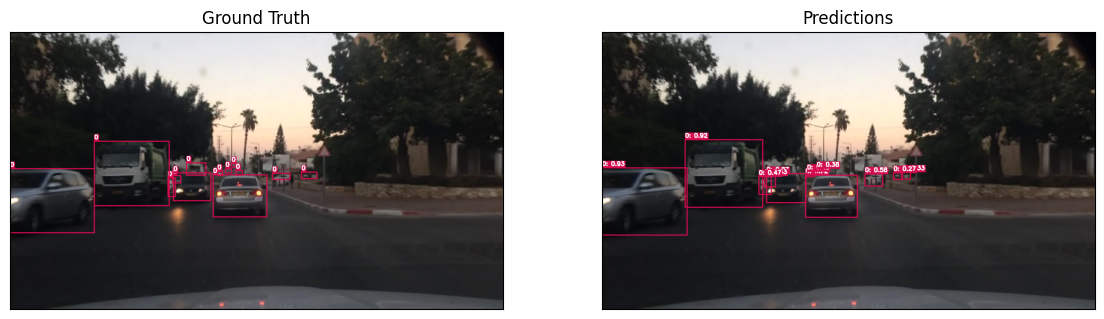

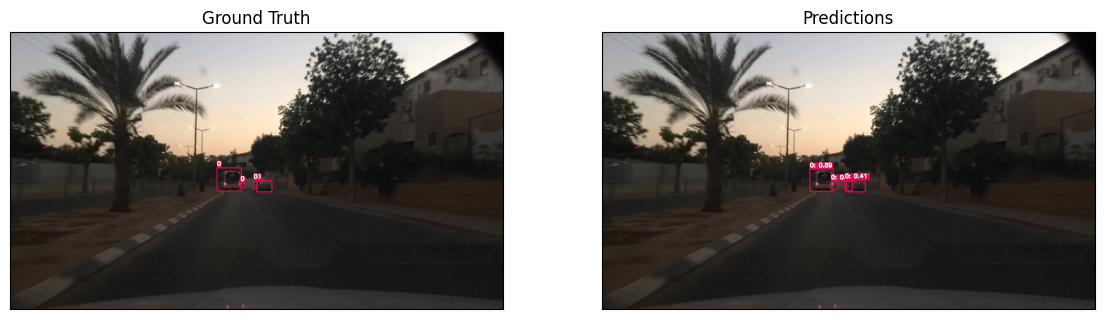

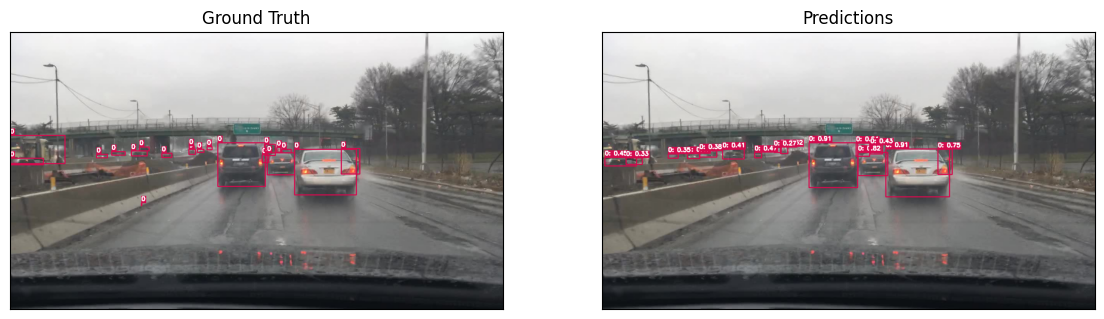

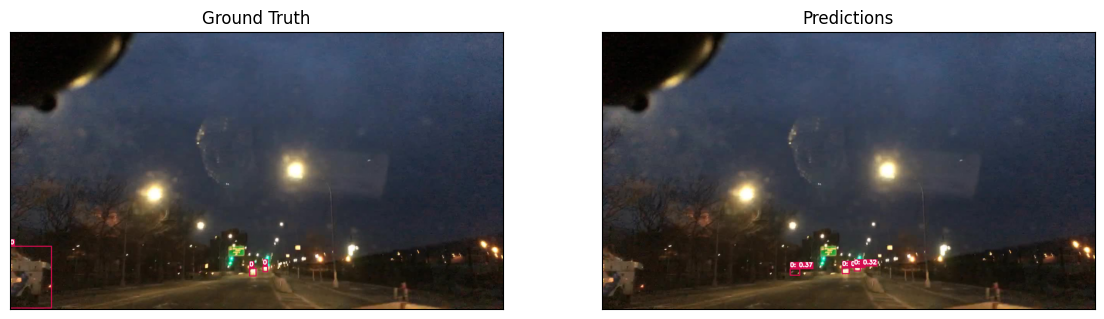

In [59]:
failed_low_sharpness_imgs = combined_df[(combined_df["failure"] == True) & (combined_df["sharpness"] <3)]["image_name"].unique()
imgs_to_show = 10
for img_name in failed_low_sharpness_imgs[:imgs_to_show]:
    filtered_dataset_stats.get_file_stats(img_name)[0].plot()

### Analyse Impact of weather condition

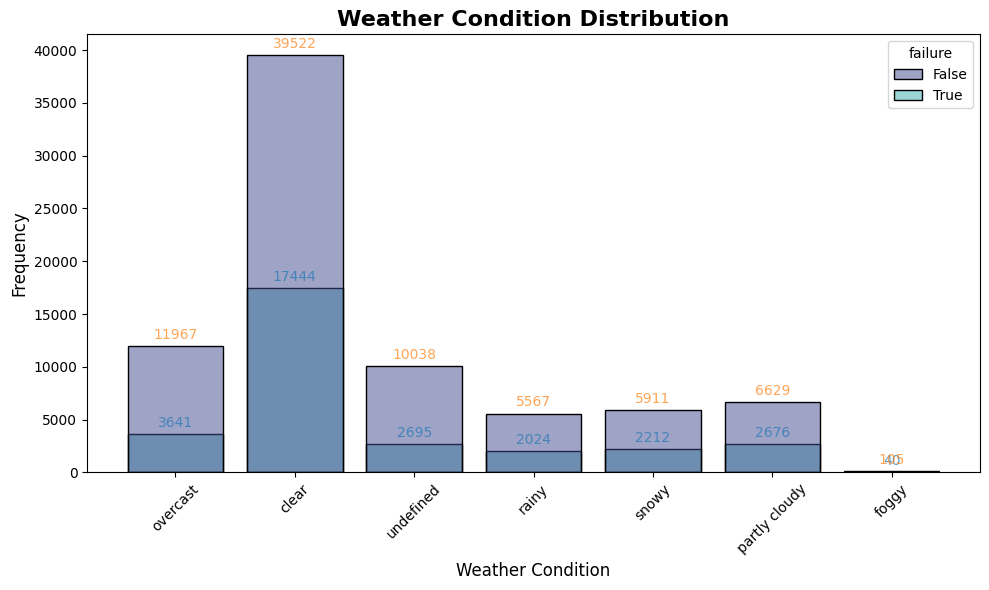

In [60]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(data=combined_df, x="image_weather", hue="failure", shrink=0.8, palette="mako", kde=False)
for container, hue_value in zip(ax.containers, combined_df["failure"].unique()):
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10, padding=3, color=sns.color_palette("tab10")[list(combined_df["failure"].unique()).index(hue_value)], alpha=0.7)

ax.set_title("Weather Condition Distribution", fontsize=16, fontweight='bold')
ax.set_xlabel("Weather Condition", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

The distribution is proportional, hence no impact

### Check impct of image scene

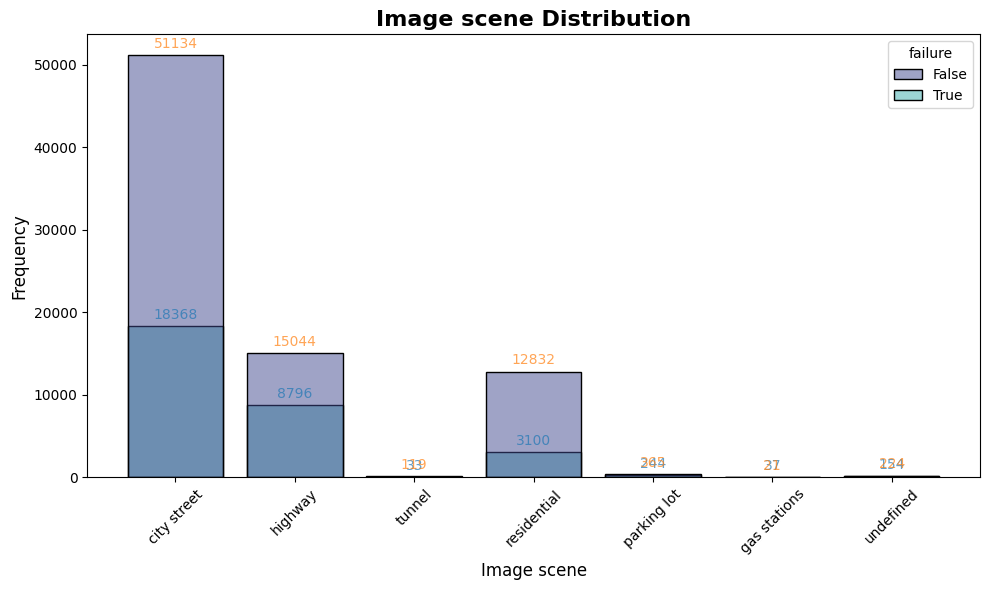

In [61]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(data=combined_df, x="image_scene",hue="failure", shrink=0.8, palette="mako", kde=False)
for container, hue_value in zip(ax.containers, combined_df["failure"].unique()):
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10, padding=3, color=sns.color_palette("tab10")[list(combined_df["failure"].unique()).index(hue_value)], alpha=0.7)

ax.set_title("Image scene Distribution", fontsize=16, fontweight='bold')
ax.set_xlabel("Image scene", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Highway images are showling significant failure cases

### Analyse impact of image capturing time

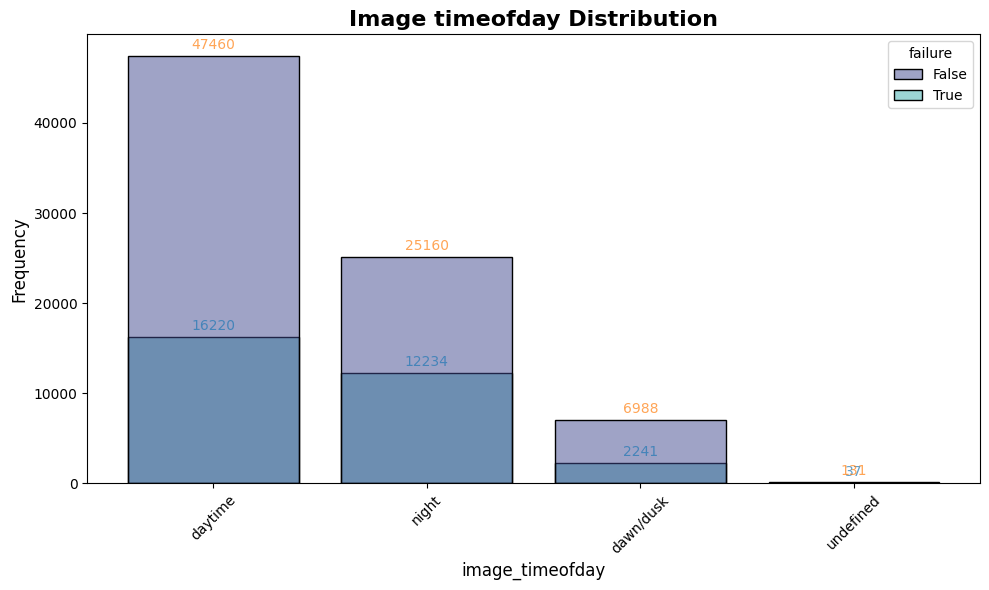

In [62]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(data=combined_df, x="image_timeofday",hue="failure", shrink=0.8, palette="mako", kde=False)
for container, hue_value in zip(ax.containers, combined_df["failure"].unique()):
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10, padding=3, color=sns.color_palette("tab10")[list(combined_df["failure"].unique()).index(hue_value)], alpha=0.7)

ax.set_title("Image timeofday Distribution", fontsize=16, fontweight='bold')
ax.set_xlabel("image_timeofday", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Night images shows increase in failure cases

#### Check impact annotation size

In [63]:
combined_df["bbox_w"] = combined_df["x2"] - combined_df["x1"]
combined_df["bbox_h"] = combined_df["y2"] - combined_df["y1"]
combined_df["bbox_area"] = combined_df["bbox_w"] * combined_df["bbox_h"]

### Impact of width

/tmp/ipykernel_560257/3434612704.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)


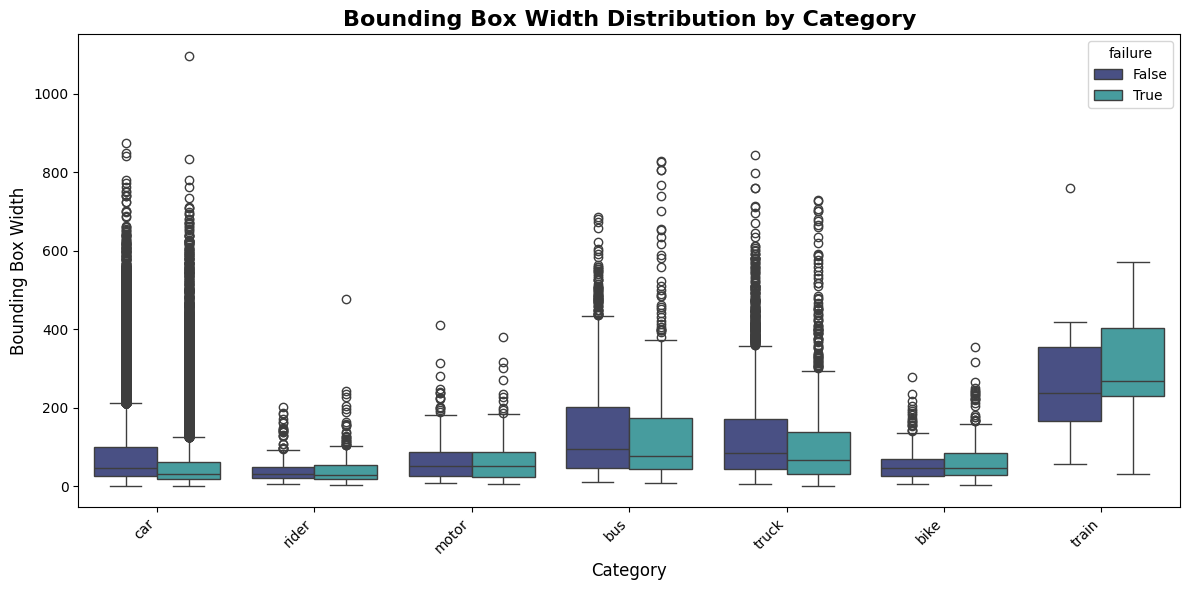

In [64]:
plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=combined_df, x="category", y="bbox_w",hue = "failure", palette="mako")

# Add a title and labels
ax.set_title("Bounding Box Width Distribution by Category", fontsize=16, fontweight='bold')
ax.set_xlabel("Category", fontsize=12)
ax.set_ylabel("Bounding Box Width", fontsize=12)

# Rotate x-axis labels for better readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

### Impact of height

/tmp/ipykernel_560257/3812388135.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)


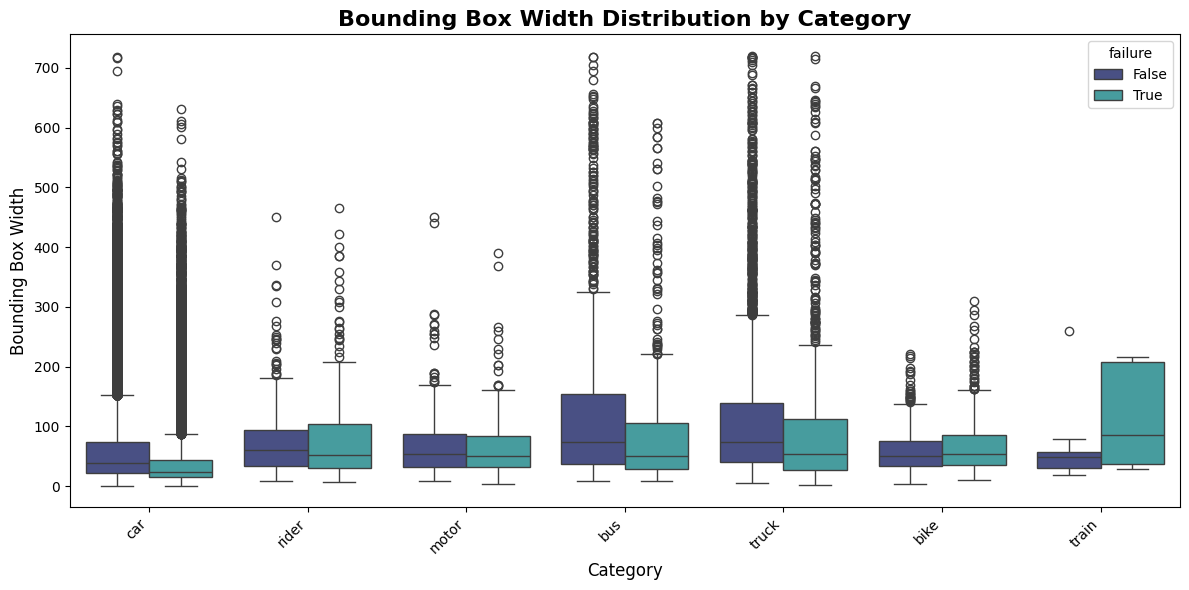

In [65]:
plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=combined_df, x="category", y="bbox_h",hue = "failure", palette="mako")

# Add a title and labels
ax.set_title("Bounding Box Width Distribution by Category", fontsize=16, fontweight='bold')
ax.set_xlabel("Category", fontsize=12)
ax.set_ylabel("Bounding Box Width", fontsize=12)

# Rotate x-axis labels for better readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

As car is the major category, we can say the failure cases are having small width and height. The same impact can be seen in case of bus and truck.
While bike and train show reverse trend, failure case prediction has bigger bboxes.

### analyse occluded and truncated cases

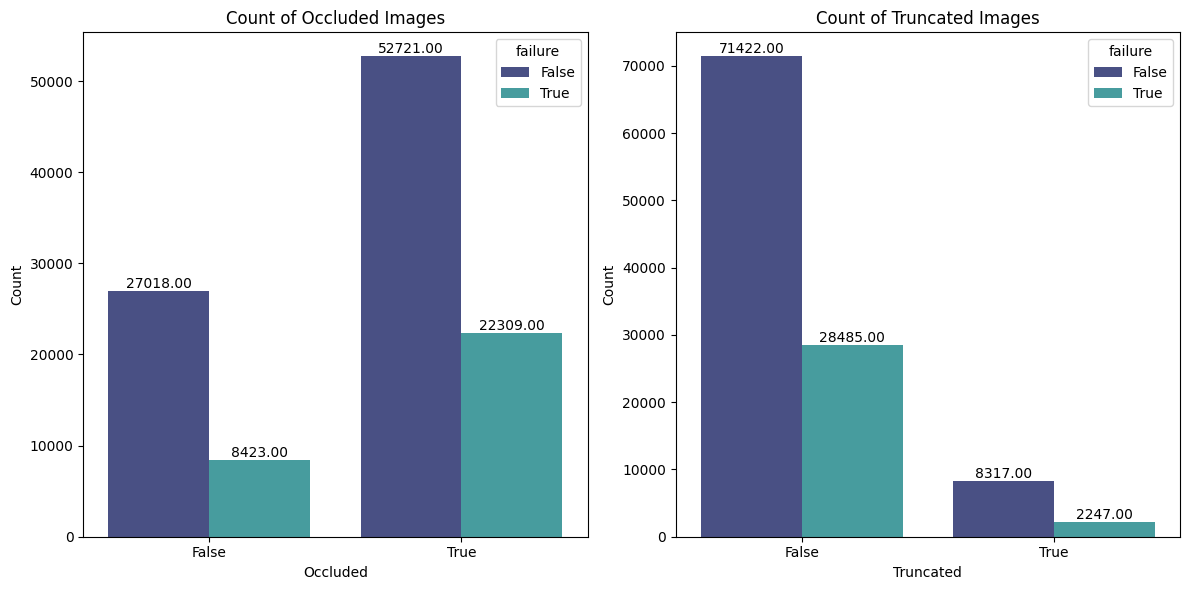

In [67]:
plt.figure(figsize=(12, 6))

# Countplot for occluded images
plt.subplot(1, 2, 1)
ax1 = sns.countplot(data=combined_df, x="occluded", hue = "failure",palette="mako")

# Annotate bars with mean values
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f', label_type='edge', fontsize=10)

plt.title("Count of Occluded Images")
plt.xlabel("Occluded")
plt.ylabel("Count")

# Countplot for truncated images
plt.subplot(1, 2, 2)
ax2 = sns.countplot(data=combined_df, x="truncated",hue = "failure", palette="mako")
# Annotate bars with mean values
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f', label_type='edge', fontsize=10)

plt.title("Count of Truncated Images")
plt.xlabel("Truncated")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

There is slight indication that occulded cases are more in failure case. There is no significant impact on Truncated cases

## Analysis

1. There is impact of Bluriness on model predictions
2. There is impact of low light Night images.
3. There is slight impact of occlusion on predcitions.
4. There is impact of small annotations.



## Future Improvements

1. Train model as multi-class problem for better handling of different classes.
2. Include more augmentations related to blur and noise.
3. Try better architecture, as Yolo generally does not performs well on small and occluded objects.
4. Clean subjective annotations